In [1]:
!pip install ultralytics
!pip install easyocr
!pip install opencv-python-headless
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 20.4 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
import re
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolov8n.pt")

In [4]:
reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [5]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(
          document.documentElement.scrollHeight,
          true
      );

      await new Promise((resolve) =>
          capture.onclick = resolve
      );

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
          video,
          0,
          0
      );

      stream.getVideoTracks()[0].stop();

      div.remove();

      return canvas.toDataURL(
          'image/jpeg',
          quality
      );
    }
    ''')

    display(js)

    data = eval_js(
        'takePhoto({})'.format(quality)
    )

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [12]:
image_path = take_photo()

<IPython.core.display.Javascript object>

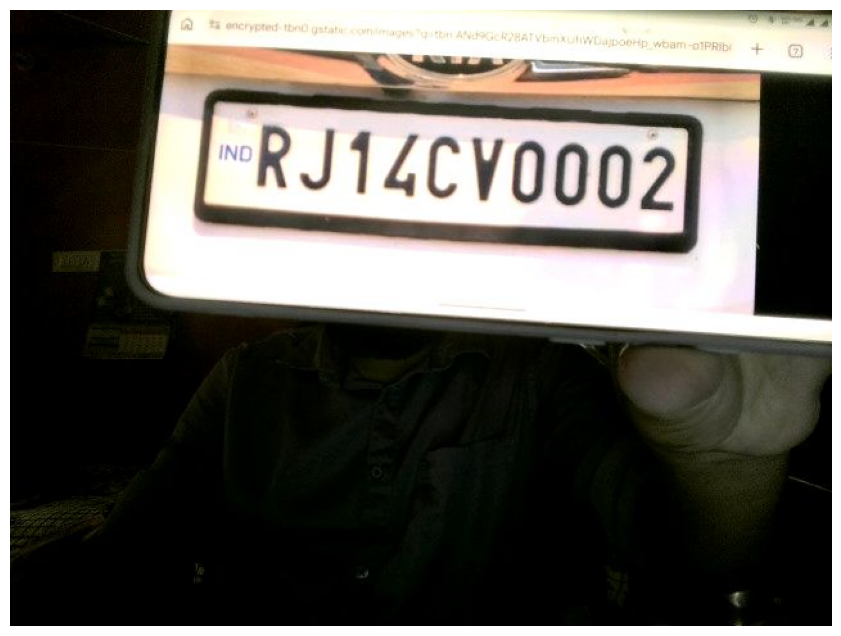

In [13]:
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [14]:
results = model(img)


0: 480x640 1 tv, 433.6ms
Speed: 8.7ms preprocess, 433.6ms inference, 45.7ms postprocess per image at shape (1, 3, 480, 640)


In [15]:
for r in results:

    boxes = r.boxes.xyxy.cpu().numpy()

    for box in boxes:

        x1, y1, x2, y2 = map(int, box[:4])

        # Crop plate
        plate = img[y1:y2, x1:x2]

        # Preprocessing
        gray = cv2.cvtColor(
            plate,
            cv2.COLOR_BGR2GRAY
        )

        blur = cv2.GaussianBlur(
            gray,
            (5,5),
            0
        )

        thresh = cv2.threshold(
            blur,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )[1]

        # OCR
        ocr_result = reader.readtext(thresh)

        plate_text = ""

        for detection in ocr_result:

            text = detection[-2]

            plate_text += text

        plate_text = plate_text.replace(" ", "")
        plate_text = plate_text.upper()

        print("Detected Plate:", plate_text)

        # Draw rectangle
        cv2.rectangle(
            img_rgb,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

        # Display text
        cv2.putText(
            img_rgb,
            plate_text,
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,255,0),
            2
        )

Detected Plate: RJIZCV0002


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [16]:
pattern = r'^[A-Z]{2}[0-9]{1,2}[A-Z]{1,2}[0-9]{4}$'

if re.match(pattern, plate_text):
    print("Valid Indian Number Plate")
else:
    print("Invalid Number Plate")

Invalid Number Plate


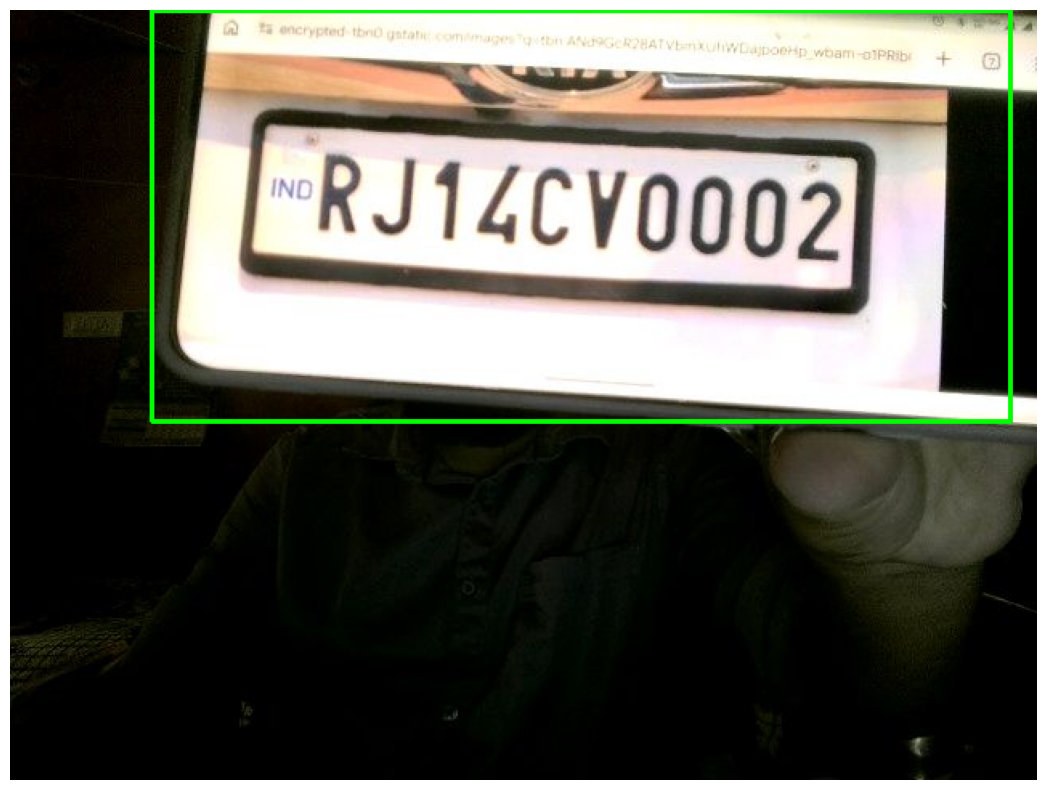

In [17]:
plt.figure(figsize=(14,10))

plt.imshow(img_rgb)

plt.axis("off")

plt.show()

<IPython.core.display.Javascript object>


0: 480x640 1 person, 1 tv, 1 microwave, 1 oven, 122.8ms
Speed: 2.8ms preprocess, 122.8ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)


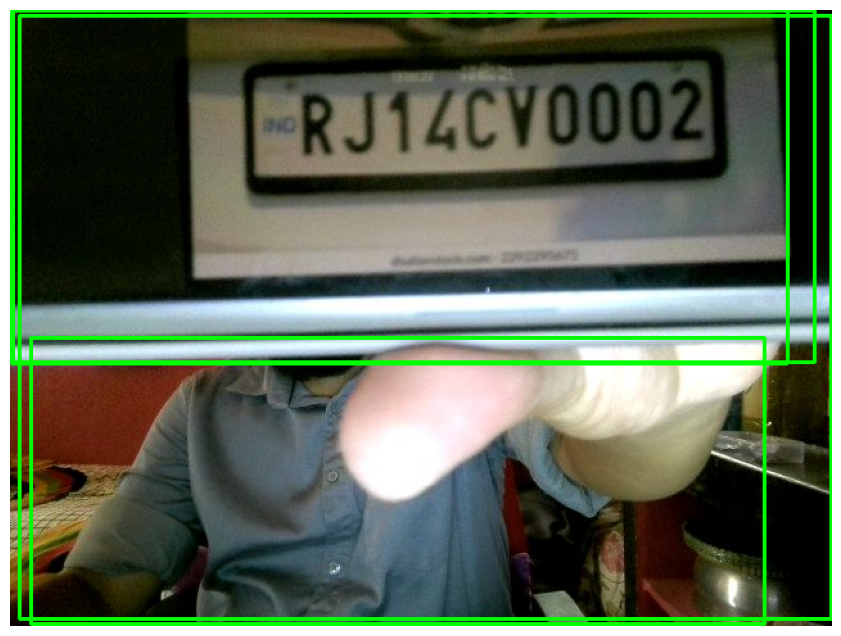

Continue? (y/n): n


In [18]:
while True:

    image_path = take_photo()

    img = cv2.imread(image_path)

    results = model(img)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    for r in results:

        boxes = r.boxes.xyxy.cpu().numpy()

        for box in boxes:

            x1, y1, x2, y2 = map(
                int,
                box[:4]
            )

            plate = img[y1:y2, x1:x2]

            text = reader.readtext(plate)

            plate_text = ""

            for t in text:
                plate_text += t[-2]

            plate_text = plate_text.upper()

            cv2.rectangle(
                img_rgb,
                (x1,y1),
                (x2,y2),
                (0,255,0),
                2
            )

            cv2.putText(
                img_rgb,
                plate_text,
                (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,255,0),
                2
            )

    plt.figure(figsize=(12,8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    choice = input("Continue? (y/n): ")

    if choice.lower() != 'y':
        break